# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
from model import EvacuationModel

%matplotlib inline
plt.style.use('default')

# Run simulation and get agent and model data

In [2]:
# Run simulations for each exit scenario
def run_evacuation_simulation(n_agents=50, width=30, height=25, num_exits=3, dt=0.1, max_steps=2000):
    """Run a single evacuation simulation (no leaders) and return dataframes."""
    num_leaders = 0
    print(f"Creating model: exits={num_exits}, leaders={num_leaders}")

    model = EvacuationModel(
        n_agents=n_agents,
        width=width,
        height=height,
        num_exits=num_exits,
        num_leaders=num_leaders,
        dt=dt
    )

    for step in range(max_steps):
        model.step()
        if not model.running:
            print(f"Simulation completed at step {step}")
            break

    model_df = model.datacollector.get_model_vars_dataframe().reset_index(drop=True).copy()
    agent_df = model.datacollector.get_agent_vars_dataframe().reset_index(drop=True).copy()

    # Add metadata
    model_df["num_exits"] = num_exits
    agent_df["num_exits"] = num_exits

    return model_df, agent_df

# run for each exit count
exit_counts = [1, 2, 3]

all_model_dfs = []
all_agent_dfs = []

for exits in exit_counts:
    model_df, agent_df = run_evacuation_simulation(num_exits=exits)
    all_model_dfs.append(model_df)
    all_agent_dfs.append(agent_df)

# combine results
combined_model_df = pd.concat(all_model_dfs, ignore_index=True)
combined_agent_df = pd.concat(all_agent_dfs, ignore_index=True)

print("All simulations completed.")
print(f"Combined Model DataFrame shape: {combined_model_df.shape}")
print(f"Combined Agent DataFrame shape: {combined_agent_df.shape}")


Creating model: exits=1, leaders=0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1785
Creating model: exits=2, leaders=0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Creating model: exits=3, leaders=0


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


All simulations completed.
Combined Model DataFrame shape: (5786, 25)
Combined Agent DataFrame shape: (159803, 15)


# Optional
## Save to pickle

In [ ]:
import os

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save to pickle
with open('data/model_data_exits.pkl', 'wb') as f:
    pickle.dump(model_df, f)

with open('data/agent_data_exits.pkl', 'wb') as f:
    pickle.dump(agent_df, f)

## Load pickle 

In [4]:
# with open('data/model_data.pkl', 'rb') as f:
#     model_df = pickle.load(f)

# with open('data/agent_data.pkl', 'rb') as f:
#     agent_df = pickle.load(f)

# print("Data loaded from pickle files")

# Analysis

## Stats over time

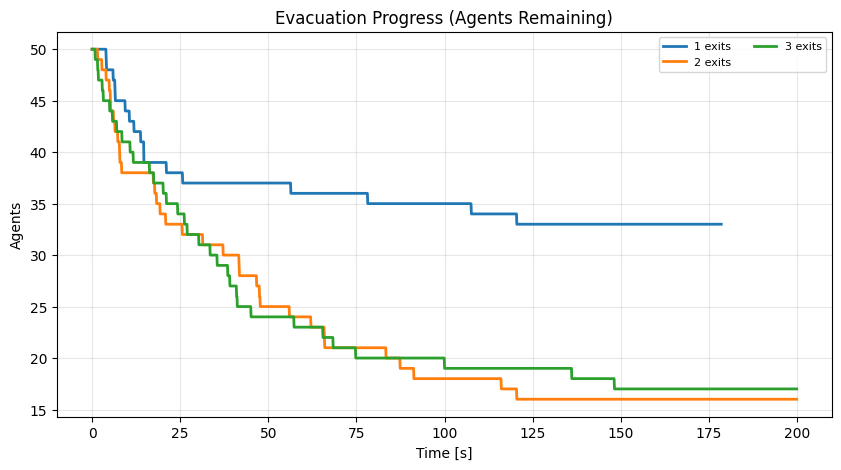

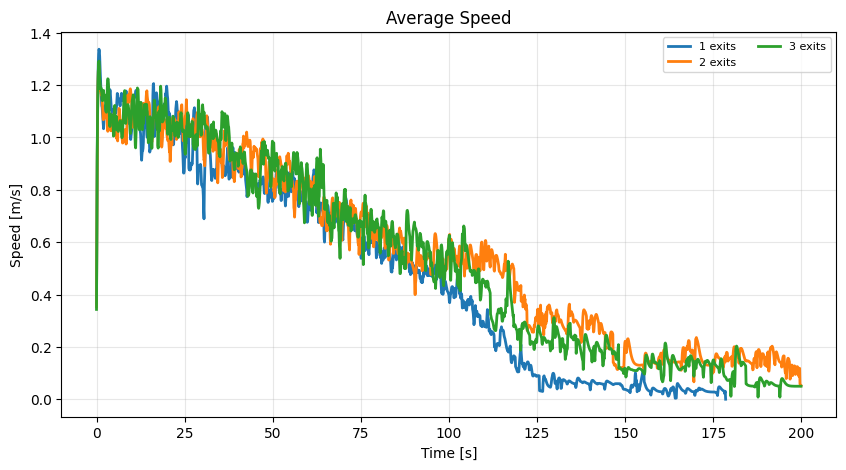

In [6]:
# exits
exit_counts = sorted(combined_model_df['num_exits'].unique())

def plot_by_exit(ycol, title, ylabel, kind='line', cumulative=False, smooth=False, per_exit=False, dt=0.1):
    """Plot model variable across exit configurations (no leaders)."""
    plt.figure(figsize=(10, 5))

    for exits in exit_counts:
        df = combined_model_df[combined_model_df['num_exits'] == exits]

        if ycol not in df.columns:
            continue

        t = np.arange(len(df)) * dt
        y = df[ycol]
        if cumulative:
            y = y.cumsum()
        if smooth:
            window = max(1, int(2.0 / dt))  # ~2s window
            y = y.rolling(window, min_periods=1).mean()

        label = f"{exits} exits"
        plt.plot(t, y, linewidth=2, label=label)

    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel(ylabel)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 1) Evacuation progress ---
plot_by_exit('Agents', 'Evacuation Progress (Agents Remaining)', 'Agents')

# --- 2) Average speed ---
plot_by_exit('Average_Speed', 'Average Speed', 'Speed [m/s]')

In [7]:
def run_evacuation_simulation(n_agents=50, width=30, height=25, num_exits=3, leader_percentage=0, dt=0.1, max_steps=2000):
    """Run a single evacuation simulation and return dataframes."""
    num_leaders = int(n_agents * leader_percentage / 100)
    print(f"\nCreating model: exits={num_exits}, leaders={num_leaders} ({leader_percentage}%)")
    
    model = EvacuationModel(n_agents=n_agents, width=width, height=height,
                            num_exits=num_exits, num_leaders=num_leaders, dt=dt)
    
    for step in range(max_steps):
        model.step()
        if not model.running:
            print(f"Simulation completed at step {step}")
            break
    
    model_df = model.datacollector.get_model_vars_dataframe().copy()
    agent_df = model.datacollector.get_agent_vars_dataframe().copy()

    # Add metadata for easy grouping later
    model_df["leader_percentage"] = leader_percentage
    agent_df["leader_percentage"] = leader_percentage
    
    return model_df, agent_df


# all leader options
leader_percentage = [0, 2, 6, 10, 20]

all_model_dfs = []
all_agent_dfs = []

for percentage in leader_percentage:
    model_df, agent_df = run_evacuation_simulation(leader_percentage=percentage)
    all_model_dfs.append(model_df)
    all_agent_dfs.append(agent_df)

# combine results
combined_model_df = pd.concat(all_model_dfs, ignore_index=True)
combined_agent_df = pd.concat(all_agent_dfs, ignore_index=True)

print("All simulations completed.")
print(f"Combined Model DataFrame shape: {combined_model_df.shape}")
print(f"Combined Agent DataFrame shape: {combined_agent_df.shape}")


Creating model: exits=3, leaders=0 (0%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)



Creating model: exits=3, leaders=1 (2%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1422

Creating model: exits=3, leaders=3 (6%)


...

c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)



Creating model: exits=3, leaders=10 (20%)


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\mesa\space.py:1337: UserWarning: Random number generator not specified, this can make models non-reproducible. Please pass a random number generator explicitly
  return AgentSet(agents, random=rng)


Simulation completed at step 1962
All simulations completed.
Combined Model DataFrame shape: (9318, 25)
Combined Agent DataFrame shape: (190246, 15)


C:\Users\User\AppData\Local\Temp\ipykernel_22112\3900198184.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined_agent_df = pd.concat(all_agent_dfs, ignore_index=True)


In [ ]:
import os

# Create data directory if it doesn't exist
os.makedirs('data', exist_ok=True)

# Save to pickle
with open('data/model_data_leaders.pkl', 'wb') as f:
    pickle.dump(model_df, f)

with open('data/agent_data_leaders.pkl', 'wb') as f:
    pickle.dump(agent_df, f)

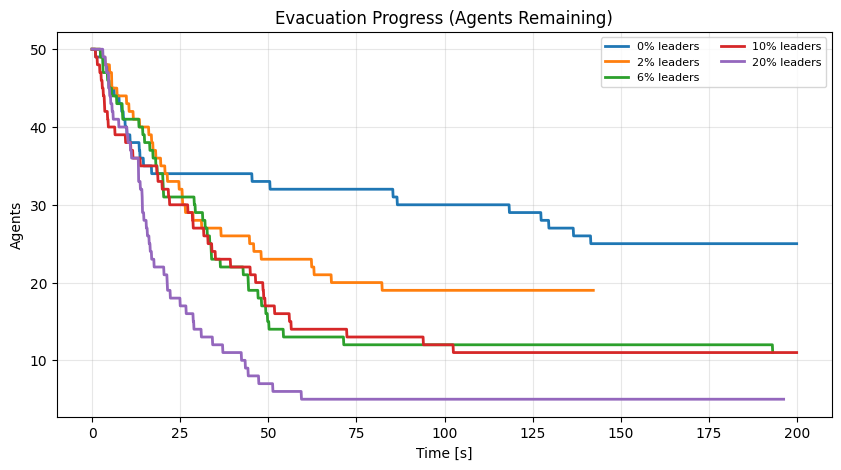

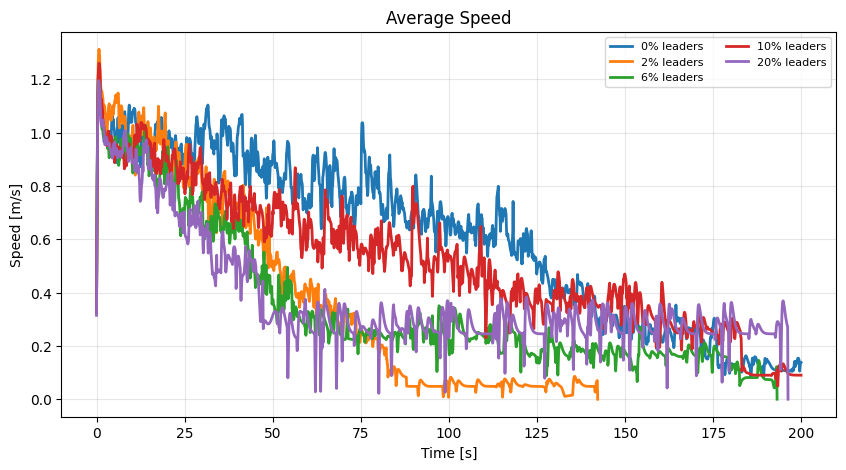

In [8]:
# leaders
leader_counts = sorted(combined_model_df['leader_percentage'].unique())

def plot_by_leader(ycol, title, ylabel, kind='line', cumulative=False, smooth=False, dt=0.1):
    """Plot model variable across leader percentages."""
    plt.figure(figsize=(10, 5))

    for percentage in leader_percentage:
        df = combined_model_df[combined_model_df['leader_percentage'] == percentage]

        if ycol not in df.columns:
            continue

        t = np.arange(len(df)) * dt
        y = df[ycol]
        if cumulative:
            y = y.cumsum()
        if smooth:
            window = max(1, int(2.0 / dt))  # ~2s window
            y = y.rolling(window, min_periods=1).mean()

        label = f"{percentage}% leaders"
        plt.plot(t, y, linewidth=2, label=label)

    plt.title(title)
    plt.xlabel('Time [s]')
    plt.ylabel(ylabel)
    plt.legend(fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.show()

# --- 1) Evacuation progress ---
plot_by_leader('Agents', 'Evacuation Progress (Agents Remaining)', 'Agents')

# --- 2) Average speed ---
plot_by_leader('Average_Speed', 'Average Speed', 'Speed [m/s]')